# Laboratory work 2

### Dependencies

In [1]:
%matplotlib ipympl

import mujoco
import time
import itertools
import numpy as np
from numpy import pi, sin, cos
import mediapy as media
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path
import enum
from tqdm import tqdm

import os
os.environ['MUJOCO_GL'] = 'osmesa'
os.environ['__NV_PRIME_RENDER_OFFLOAD'] = '1'
os.environ['__GLX_VENDOR_LIBRARY_NAME'] = 'nvidia'

model_dir = Path("mujoco_menagerie/boston_dynamics_spot/scene_arm_vel.xml")
model_xml = model_dir / "scene_arm_vel.xml"
model = mujoco.MjModel.from_xml_path(str(model_dir))
data = mujoco.MjData(model)

class Resolution(enum.Enum):
  SD = (480, 640)
  HD = (720, 1280)
  UHD = (2160, 3840)

res = Resolution.SD
h, w = res.value

model.vis.global_.offheight = h
model.vis.global_.offwidth = w
camera = mujoco.MjvCamera()
mujoco.mjv_defaultFreeCamera(model, camera)
# camera.azimuth = -90
# camera.elevation = 0
camera.distance = 3

renderer = mujoco.Renderer(model, height=h, width=w)

fps = 30
duration = 5.0
ctrl_rate = 2
ctrl_std = 0.05
frames = []

vis = mujoco.MjvOption()
vis.geomgroup[2] = True
vis.geomgroup[3] = False
coll = mujoco.MjvOption()
coll.geomgroup[2] = False
coll.geomgroup[3] = True
coll.flags[mujoco.mjtVisFlag.mjVIS_CONVEXHULL] = True

nsteps = int(np.ceil(duration / model.opt.timestep))

In [2]:
joints = ["arm_sh0", "arm_sh1", "arm_el0", "arm_el1", "arm_wr0", "arm_wr1", "arm_f1x"]
actuators = ["arm_sh0_vel", "arm_sh1_vel", "arm_el0_vel", "arm_el1_vel", "arm_wr0_vel", "arm_wr1_vel", "arm_f1x_vel"]
bodies = ["arm_link_sh0", "arm_link_sh1", "arm_link_el0", "arm_link_el1", "arm_link_wr0", "arm_link_wr1", "arm_link_fngr"]

class DH_params():
    def __init__(self):
        self.a = np.zeros(6)
        self.d = np.zeros(6)
        self.alpha = np.zeros(6)
        self.theta = np.zeros(6)
    def add_theta(self, q):
        self.theta += q
    def reset_theta(self):
        self.theta = np.zeros(6)
        self.theta[2] = pi/2
    def T_matrix(self, i):
        return np.array([
            [cos(self.theta[i]),    -sin(self.theta[i])*cos(self.alpha[i]),     sin(self.theta[i])*sin(self.alpha[i]),      self.a[i]*cos(self.theta[i])],
            [sin(self.theta[i]),    cos(self.theta[i])*cos(self.alpha[i]),      -cos(self.theta[i])*sin(self.alpha[i]),     self.a[i]*sin(self.theta[i])],
            [0,                     sin(self.alpha[i]),                         cos(self.alpha[i]),                         self.d[i]],
            [0,                     0,                                          0,                                          1]
            ])
    
       

l1 = 0.12
l2 = 0.339
l3 = 0.403
h3 = 0.075
l5 = 0.117
h6 = 0.015

DH = DH_params()
DH.alpha = np.array([   -pi/2,  0,      pi/2,   -pi/2,  pi/2,   pi/2])
DH.a = np.array([       0,      l2,     -h3,    0,      0,      -h6])
DH.d = np.array([       0,      0,      0,      l3,     0,      l5])
DH.theta = np.array([   0.,     0.,     pi/2,   0.,     0.,     0.])


def calc_Jacobian(DH_params, p_endeff):
    J = np.zeros((6, 6))
    T = np.eye(4)
    for i in range(6):
        z_i = T[0:3, 2]
        p_i = T[0:3, 3]
        J[0:3, i] = np.cross(z_i, (p_endeff - p_i))
        J[3:6, i] = z_i
        A = DH_params.T_matrix(i)
        T = T @ A
    return J

def print_p_q(bodies, joints):
    p0 = data.body("arm_link_sh0").xpos
    for body, joint in zip(bodies, joints):
        print(f'{body}\t{np.round(data.body(body).xpos - p0, 3)}\t{np.round(data.joint(joint).qpos, 3)}')

def forward_kinematics(DH_params, count):
    T = np.eye(4)
    for i in range(count):
        A = DH.T_matrix(i)
        T = T @ A
    return T

def reset_position(data, joints, DH):
    set_q = np.array([0., 0., 0., 0., 0., 0.])
    for i, joint in zip(range(0, 6), joints):
        data.joint(joint).qpos = set_q[i]
    DH.reset_theta()

def set_position(data, joints, set_q, DH):
    reset_position(data, joints, DH)
    for i, joint in zip(range(0, 6), joints):
        data.joint(joint).qpos = set_q[i]
    DH.add_theta(set_q)

def calc_euler(R):
    theta = np.arccos(R[2, 2])
    if ((R[2, 2] != 1) and (R[2, 2] != -1)):
        phi = np.atan2(R[1, 2], R[0, 2])
        psi = np.atan2(R[2, 1], -R[2, 0])
    elif (R[2, 2] == 1):
        psi = 0
        theta = np.atan2(R[1, 0], R[0, 0])
    elif (R[2, 2] == -1):
        psi = 0
        theta = np.atan2(-R[0, 1], R[0, 0])
    return phi, theta, psi

def set_vel(data, model, actuators, vel):
    for i, actuator in zip(range(6), actuators):
        data.ctrl[model.actuator(actuator).id] = vel[i]

def solve_ik_velocity(J, vel_e, epsilon=1e-6):
    cond = np.linalg.cond(J)
    if cond > 1/epsilon:
        print(f"Предупреждение: матрица близка к вырожденной (cond={cond:.2f})")
        return np.linalg.pinv(J) @ vel_e
    else:
        return np.linalg.solve(J, vel_e)  # или np.linalg.inv(J) @ vel_e

""

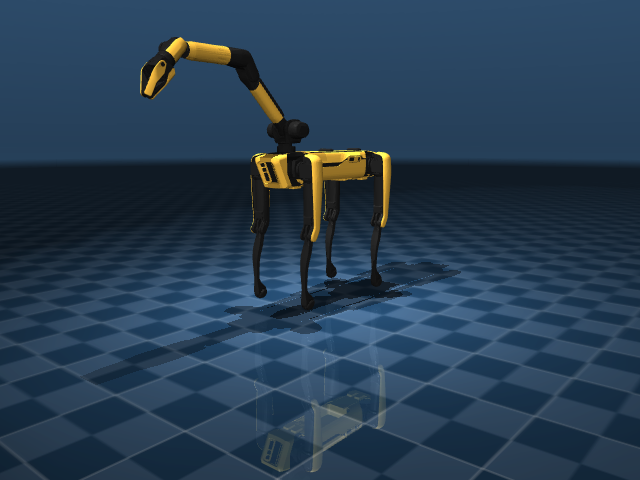

In [3]:
set_q = np.array([0., -pi/4, pi/4, 0., pi/4, 0.])
set_position(data, joints, set_q, DH)

mujoco.mj_forward(model, data)
renderer.update_scene(data, camera)
media.show_image(renderer.render())

In [4]:
p_e = data.body("arm_link_fngr").xpos - data.body("arm_link_sh0").xpos
print(f'Initial position:')
print(f'q:\t{set_q}')
print(f'p_e:\t{p_e}\n')
J = calc_Jacobian(DH, p_e)

q_dot = np.array([0., 0.142, -0.5, 0., 0.456, 0.])
vel_e = np.dot(J, q_dot)
print(f'Jacobian:\n{np.round(J, 3)}\n')
print(f'FK:\tendeff vel:\t{np.round(vel_e, 3)}')

target_p_e = np.array([0., 0., 0.1, 0., 0.1, 0.])
q_dot_target = solve_ik_velocity(J, target_p_e)
print(f"IK:\ttarget IK q:\t{np.round(q_dot_target, 3)}")

Initial position:
q:	[ 0.         -0.78539816  0.78539816  0.          0.78539816  0.        ]
p_e:	[0.73618466 0.         0.24178528]

Jacobian:
[[ 0.     0.242  0.002 -0.    -0.073 -0.   ]
 [ 0.736  0.     0.     0.073  0.    -0.015]
 [ 0.    -0.736 -0.496 -0.    -0.093 -0.   ]
 [ 0.     0.     0.     1.     0.     0.707]
 [ 0.     1.     1.     0.     1.     0.   ]
 [ 1.     0.     0.     0.     0.    -0.707]]

FK:	endeff vel:	[ 0.    -0.     0.101  0.     0.098  0.   ]
IK:	target IK q:	[ 0.     0.142 -0.497 -0.     0.456  0.   ]


In [5]:
'''vel = np.array([0.5, 0., 0., 0., 0., 0.])
set_vel(data, model, actuators, vel)

frames = []
for i in tqdm(range(nsteps)):
  # set_vel(data, model, actuators, vel)
  data.qvel[-2] = -0.1
  mujoco.mj_step(model, data)
  if len(frames) < data.time * fps:
    renderer.update_scene(data, camera)
    frame = renderer.render().copy().astype(np.uint8)
    frames.append(frame)
  if i % 1000 == 0:
    print(np.round(data.qvel, 2))
media.show_video(frames, fps=fps, loop=False)'''

'vel = np.array([0.5, 0., 0., 0., 0., 0.])\nset_vel(data, model, actuators, vel)\n\nframes = []\nfor i in tqdm(range(nsteps)):\n  # set_vel(data, model, actuators, vel)\n  data.qvel[-2] = -0.1\n  mujoco.mj_step(model, data)\n  if len(frames) < data.time * fps:\n    renderer.update_scene(data, camera)\n    frame = renderer.render().copy().astype(np.uint8)\n    frames.append(frame)\n  if i % 1000 == 0:\n    print(np.round(data.qvel, 2))\nmedia.show_video(frames, fps=fps, loop=False)'